In [33]:
import pandas as pd

file_path = "austria_time_series.xlsx"

# Read with multi-level headers
df = pd.read_excel(file_path, header=[0,1,2,3])

# Flatten column names
df.columns = [
    '_'.join([str(i) for i in col if str(i) != 'nan'])
    for col in df.columns
]

# Clean column names
df.columns = df.columns.str.strip().str.lower()

print(df.columns)

Index(['unnamed: 0_level_0_unnamed: 0_level_1_unnamed: 0_level_2_unnamed: 0_level_3',
       'unnamed: 1_level_0_unnamed: 1_level_1_unnamed: 1_level_2_unnamed: 1_level_3',
       'at_load_actual_entsoe_transparency_mw',
       'at_load_forecast_entsoe_transparency_mw', 'at_price_day_ahead_eur',
       'at_solar_generation_actual_mw',
       'at_wind_onshore_generation_actual_mw'],
      dtype='object')


In [34]:
df = df.rename(columns={
    'utc_timestamp': 'utc_timestamp',
    'at_load_actual_entsoe_transparency_mw': 'load_actual',
    'at_load_forecast_entsoe_transparency_mw': 'load_forecast',
    'at_price_day_ahead_eur': 'price',
    'at_solar_generation_actual_mw': 'solar',
    'at_wind_onshore_generation_actual_mw': 'wind'
})

In [35]:
# Convert UTC timestamp
df['utc_timestamp'] = pd.to_datetime(df['utc_timestamp'], errors='coerce')

# Convert to CET/CEST automatically
df['timestamp'] = (
    df['utc_timestamp']
    .dt.tz_localize('UTC')
    .dt.tz_convert('Europe/Vienna')
)

# Drop original UTC column (optional)
df = df.drop(columns=['utc_timestamp'])

KeyError: 'utc_timestamp'

In [36]:
print(df.columns.tolist())

['unnamed: 0_level_0_unnamed: 0_level_1_unnamed: 0_level_2_unnamed: 0_level_3', 'unnamed: 1_level_0_unnamed: 1_level_1_unnamed: 1_level_2_unnamed: 1_level_3', 'load_actual', 'load_forecast', 'price', 'solar', 'wind']


In [37]:
df = df.rename(columns={
    df.columns[0]: 'utc_timestamp',
    df.columns[1]: 'timestamp'
})

print(df.columns)

Index(['utc_timestamp', 'timestamp', 'load_actual', 'load_forecast', 'price',
       'solar', 'wind'],
      dtype='object')


In [38]:
df['utc_timestamp'] = pd.to_datetime(df['utc_timestamp'], errors='coerce')

df['timestamp'] = (
    df['utc_timestamp']
    .dt.tz_localize('UTC')
    .dt.tz_convert('Europe/Vienna')
)

/var/folders/dq/14lg2cn57kjdzwls1t7prqq40000gn/T/ipykernel_1464/3562253144.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['utc_timestamp'] = pd.to_datetime(df['utc_timestamp'], errors='coerce')


In [39]:
df = df.drop(columns=['utc_timestamp'])

In [40]:
df = df.sort_values('timestamp').reset_index(drop=True)

In [41]:
print(df.isna().sum())

df = df.fillna(method='ffill')

timestamp            1
load_actual          7
load_forecast        7
price            70227
solar              253
wind               199
dtype: int64


/var/folders/dq/14lg2cn57kjdzwls1t7prqq40000gn/T/ipykernel_1464/28521846.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [42]:
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

Duplicates: 1


In [43]:
df = df.set_index('timestamp')

df = df.asfreq('H')   # ensures hourly structure

df = df.fillna(method='ffill')

df = df.reset_index()

/var/folders/dq/14lg2cn57kjdzwls1t7prqq40000gn/T/ipykernel_1464/3106893369.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.asfreq('H')   # ensures hourly structure
/var/folders/dq/14lg2cn57kjdzwls1t7prqq40000gn/T/ipykernel_1464/3106893369.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [45]:
import numpy as np

numeric_cols = df.select_dtypes(include=np.number).columns

def cap_outliers(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    return np.clip(col, Q1 - 1.5*IQR, Q3 + 1.5*IQR)

for col in numeric_cols:
    df[col] = cap_outliers(df[col])

In [46]:
import numpy as np

numeric_cols = df.select_dtypes(include=np.number).columns

outlier_summary = {}

def get_outliers(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(col < lower) | (col > upper)]
    
    return outliers, lower, upper

for col in numeric_cols:
    outliers, lower, upper = get_outliers(df[col])
    
    outlier_summary[col] = {
        "count": len(outliers),
        "percentage": round(len(outliers)/len(df)*100, 2),
        "lower_bound": lower,
        "upper_bound": upper
    }

for k, v in outlier_summary.items():
    print(k, ":", v)

load_actual : {'count': 0, 'percentage': 0.0, 'lower_bound': np.float64(2780.3000000000006), 'upper_bound': np.float64(11261.1)}
load_forecast : {'count': 0, 'percentage': 0.0, 'lower_bound': np.float64(2918.2999999999997), 'upper_bound': np.float64(11026.18)}
price : {'count': 0, 'percentage': 0.0, 'lower_bound': np.float64(-3.1999999999999957), 'upper_bound': np.float64(63.99999999999999)}
solar : {'count': 0, 'percentage': 0.0, 'lower_bound': np.float64(-335.11125), 'upper_bound': np.float64(558.51875)}
wind : {'count': 0, 'percentage': 0.0, 'lower_bound': np.float64(-1303.4724999999999), 'upper_bound': np.float64(2601.5474999999997)}


In [47]:
outliers_all = pd.DataFrame()

for col in numeric_cols:
    outliers, _, _ = get_outliers(df[col])
    outliers['outlier_column'] = col
    outliers_all = pd.concat([outliers_all, outliers])

outliers_all = outliers_all.sort_values('timestamp')

print(outliers_all.head())

Empty DataFrame
Columns: [timestamp, load_actual, load_forecast, price, solar, wind, outlier_column]
Index: []


In [48]:
outliers_all['hour'] = outliers_all['timestamp'].dt.hour
outliers_all['month'] = outliers_all['timestamp'].dt.month

print("Outliers by hour:")
print(outliers_all['hour'].value_counts().sort_index())

print("\nOutliers by month:")
print(outliers_all['month'].value_counts().sort_index())

Outliers by hour:
Series([], Name: count, dtype: int64)

Outliers by month:
Series([], Name: count, dtype: int64)


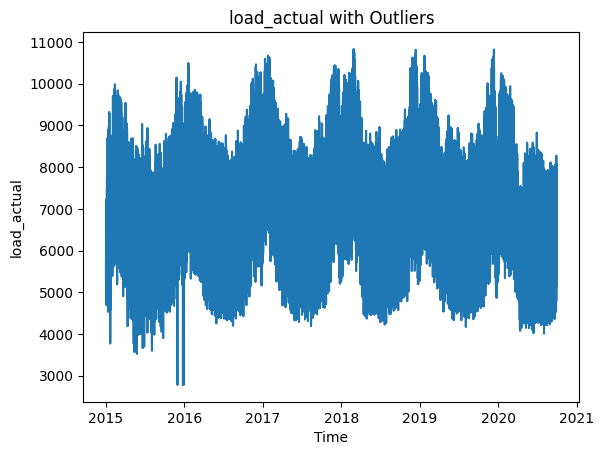

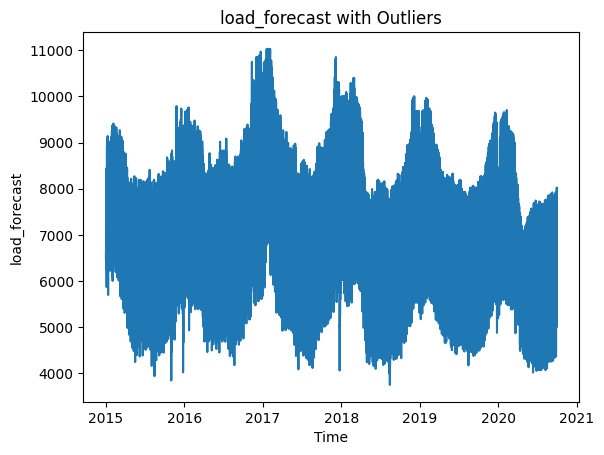

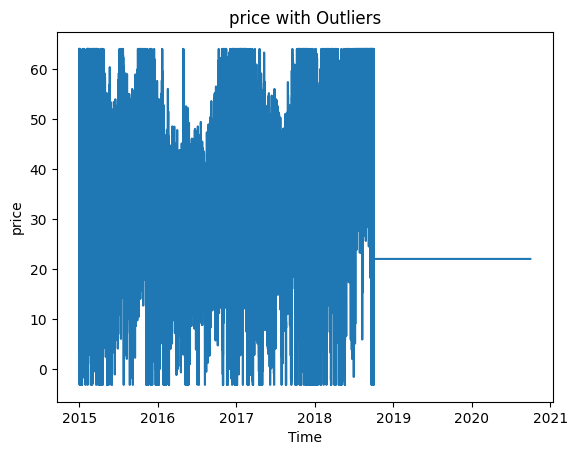

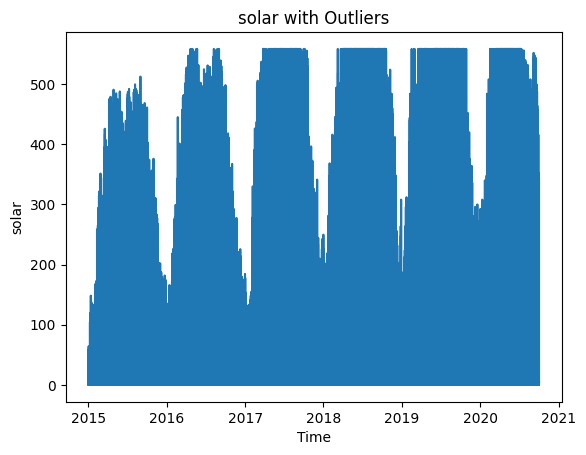

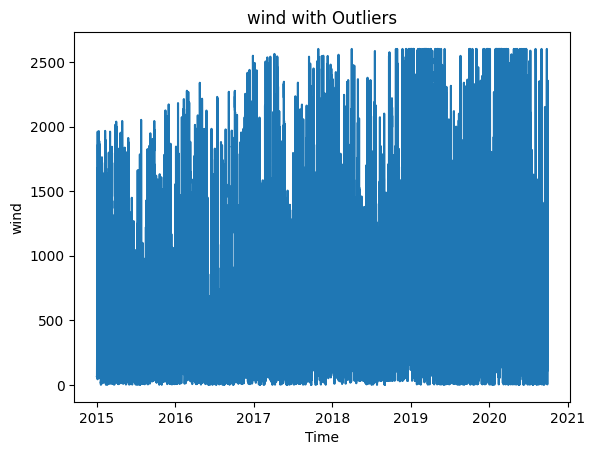

In [49]:
import matplotlib.pyplot as plt

for col in numeric_cols:
    plt.figure()
    plt.plot(df['timestamp'], df[col])
    plt.title(f"{col} with Outliers")
    plt.xlabel("Time")
    plt.ylabel(col)
    plt.show()

In [50]:
df.to_csv("austria_clean_master.csv", index=False)

In [52]:
df = pd.read_csv("austria_clean_master.csv")
df.to_excel("austria_clean_master.xlsx", index=False)

# we had a duplicate and we already handled it.
# major issue price column has huge missing values(used forward filled methode) 70k appox.(not suitable for forward filling)
better options :
interpolation, model based imputation or drop column if critical-price 
solar,wind(mkderate missing):forward fill or interpolation 
low missing :(load actual and load forcaste)-forward fill is acceptable 
# issue with timestamp: 1 issue (sampled and filled)
# time series consistency: ensure uniform interval , no duplicate timestamp ,no gap after resampling  
